In [5]:
import os
from matplotlib.colors import LogNorm
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

def get_relaxation_time(f, t):
    tau = np.interp(1 / np.e, f[::-1], t[::-1])
    if not np.min(f) < 1 / np.e:
        return np.nan
    return tau

root = '/Users/marshallmccraw/Projects/yale/data/s-26/grant/ga-data'
dynamics_data = np.load(os.path.join(root, 'ga-dynamics-data-4.npz'))
jamming_data = np.load(os.path.join(root, 'ga-jamming-data.npz'))

mu_norm = LogNorm(min(dynamics_data['mu']), max(dynamics_data['mu']))
alpha_norm = plt.Normalize(min(dynamics_data['alpha']), max(dynamics_data['alpha']))
cmap = plt.cm.viridis

In [6]:
tau_df = {
    'alpha': [],
    'mu': [],
    'phi': [],
    'tau': [],
    'tau_r': [],
    'tau_r_pi': [],
}
for alpha in np.unique(dynamics_data['alpha']):
    for mu in np.unique(dynamics_data['mu']):
        mask = (dynamics_data['mu'] == mu) & (dynamics_data['alpha'] == alpha)
        for isf, aisf, aisf_pi, t, phi in zip(
            dynamics_data['isf_small'][mask],
            dynamics_data['aisf_small'][mask],
            dynamics_data['aisf_pi_small'][mask],
            dynamics_data['t'][mask],
            dynamics_data['phi'][mask]
        ):
            tau_df['tau'].append(get_relaxation_time(isf, t))
            tau_df['tau_r'].append(get_relaxation_time(aisf, t))
            tau_df['tau_r_pi'].append(get_relaxation_time(aisf_pi, t))
            tau_df['phi'].append(phi)
            tau_df['alpha'].append(alpha)
            tau_df['mu'].append(mu)
tau_df = pd.DataFrame(tau_df)

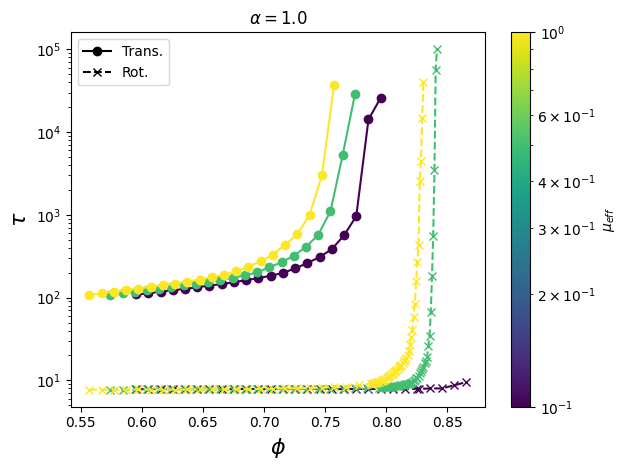

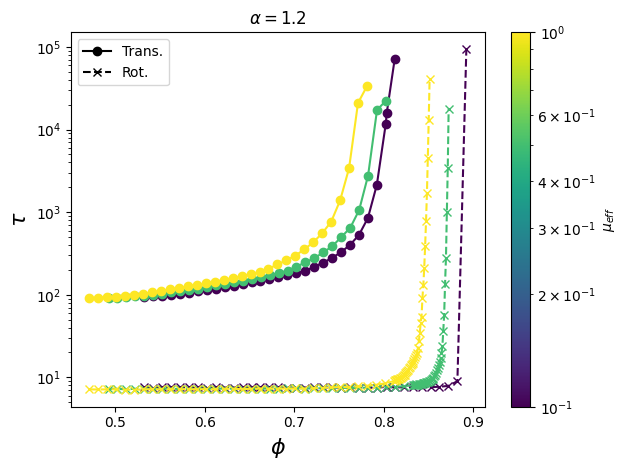

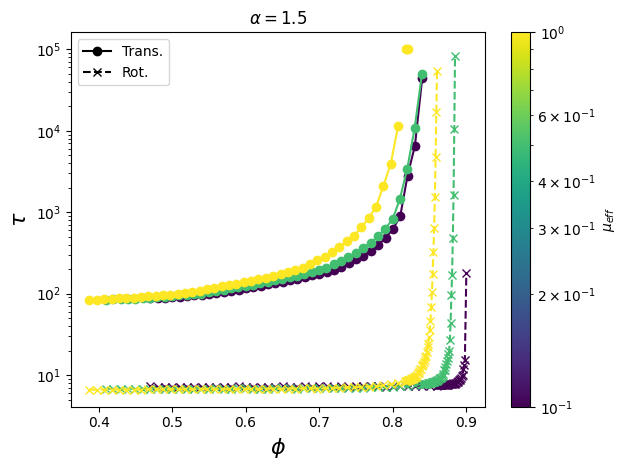

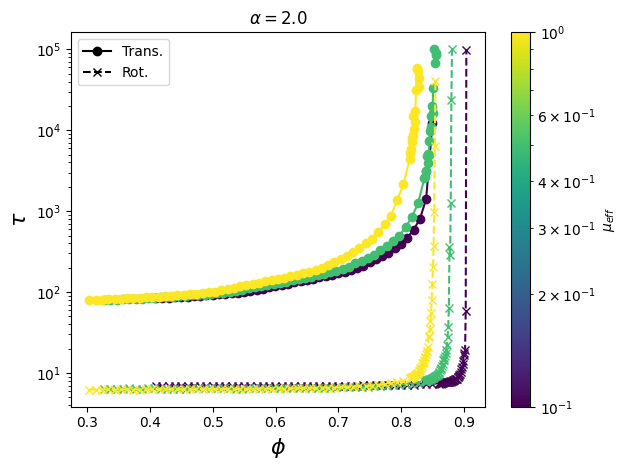

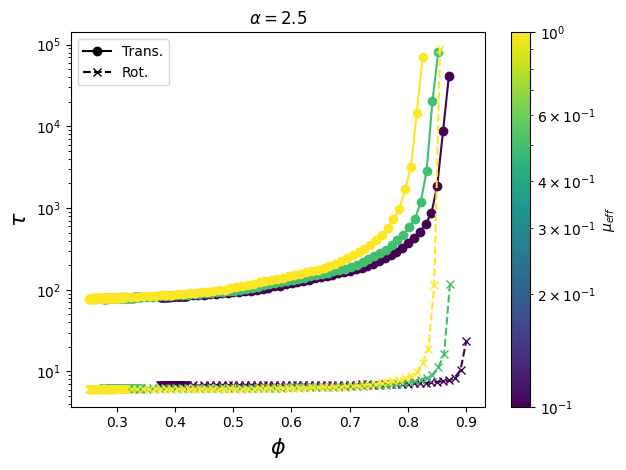

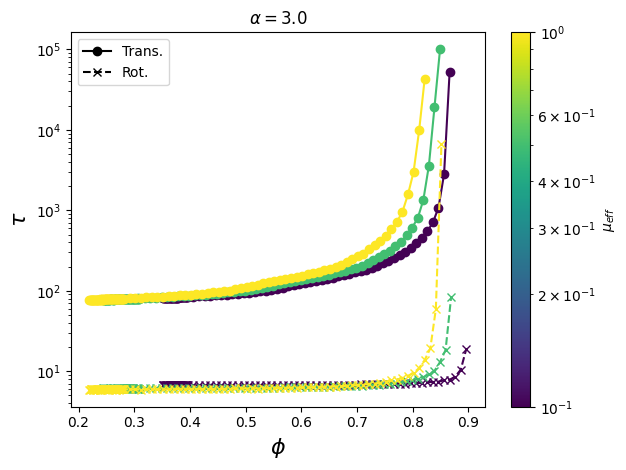

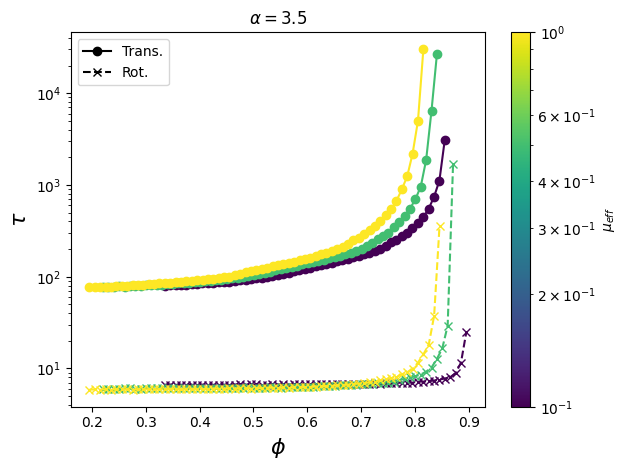

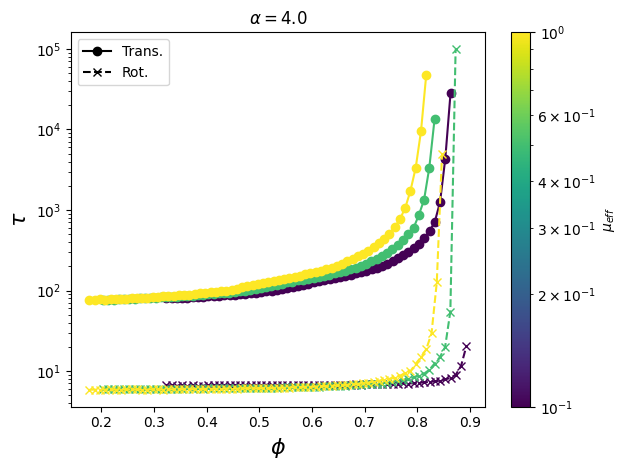

In [10]:
for alpha in pd.unique(tau_df.alpha):
    for mu in pd.unique(tau_df.mu):
        mask = (tau_df.alpha == alpha) & (tau_df.mu == mu)
        x = tau_df[mask].phi.values
        order = np.argsort(x)
        y = tau_df[mask].tau.values[order]
        y_r = tau_df[mask].tau_r.values[order]
        x = np.sort(x)
        plt.plot(x, y, c=cmap(mu_norm(mu)), marker='o')
        plt.plot(x, y_r, c=cmap(mu_norm(mu)), marker='x', linestyle='--')
    plt.plot([], [], marker='o', label='Trans.', c='k')
    plt.plot([], [], marker='x', linestyle='--', label='Rot.', c='k')
    plt.legend()
    plt.xlabel(r'$\phi$', fontsize=16)
    plt.ylabel(r'$\tau$', fontsize=16)
    plt.yscale('log')
    plt.title(fr'$\alpha=${alpha}')
    sm = plt.cm.ScalarMappable(norm=mu_norm, cmap=cmap)
    sm.set_array(pd.unique(tau_df.mu))
    cbar = plt.colorbar(sm, ax=plt.gca(), label=r'$\mu_{eff}$')
    plt.tight_layout()
    plt.savefig(f'figures/taus/alpha-{alpha}.png', dpi=600)
    plt.show()

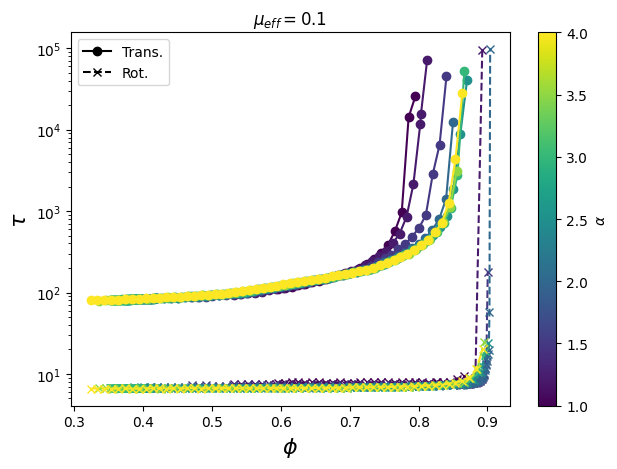

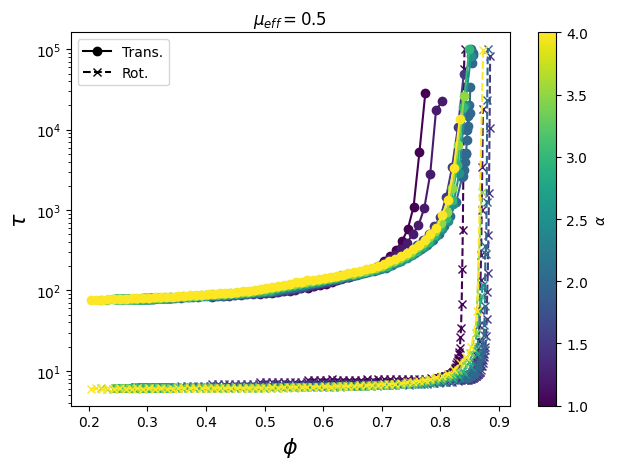

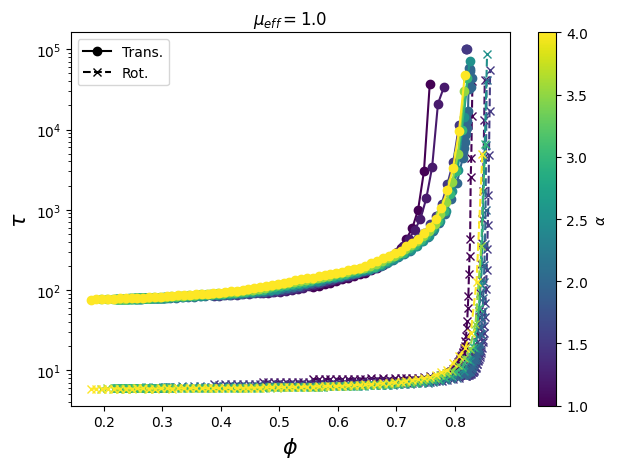

In [11]:
for mu in pd.unique(tau_df.mu):
    for alpha in pd.unique(tau_df.alpha):
        mask = (tau_df.alpha == alpha) & (tau_df.mu == mu)
        x = tau_df[mask].phi.values
        order = np.argsort(x)
        y = tau_df[mask].tau.values[order]
        y_r = tau_df[mask].tau_r.values[order]
        x = np.sort(x)
        plt.plot(x, y, c=cmap(alpha_norm(alpha)), marker='o')
        plt.plot(x, y_r, c=cmap(alpha_norm(alpha)), marker='x', linestyle='--')
    plt.plot([], [], marker='o', label='Trans.', c='k')
    plt.plot([], [], marker='x', linestyle='--', label='Rot.', c='k')
    plt.legend()
    plt.xlabel(r'$\phi$', fontsize=16)
    plt.ylabel(r'$\tau$', fontsize=16)
    plt.yscale('log')
    plt.title(fr'$\mu_{{eff}}=${mu}')
    sm = plt.cm.ScalarMappable(norm=alpha_norm, cmap=cmap)
    sm.set_array(pd.unique(tau_df.alpha))
    cbar = plt.colorbar(sm, ax=plt.gca(), label=r'$\alpha$')
    plt.tight_layout()
    plt.show()

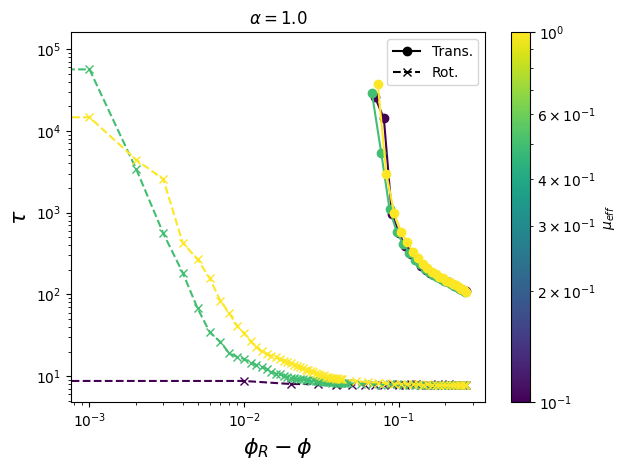

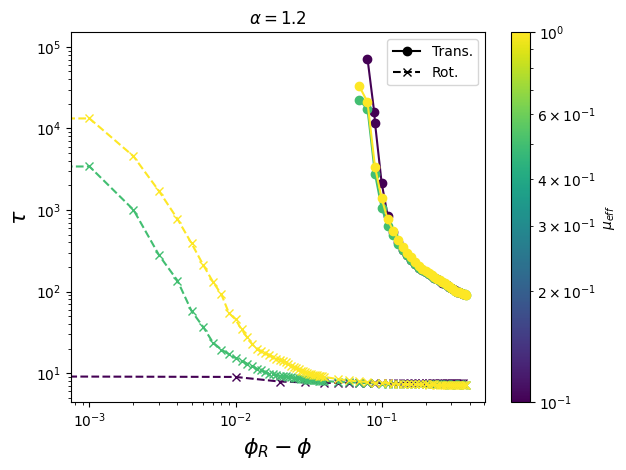

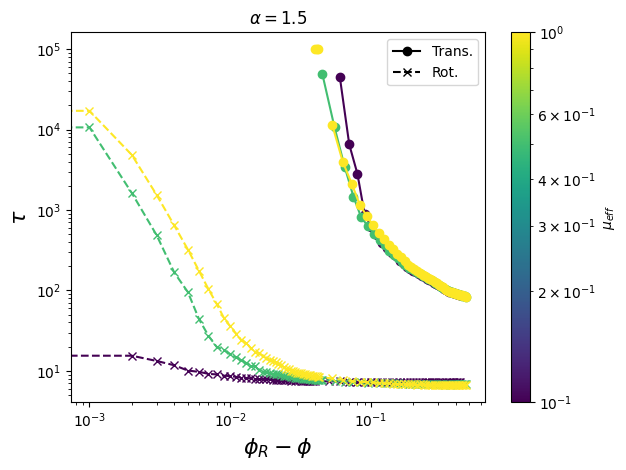

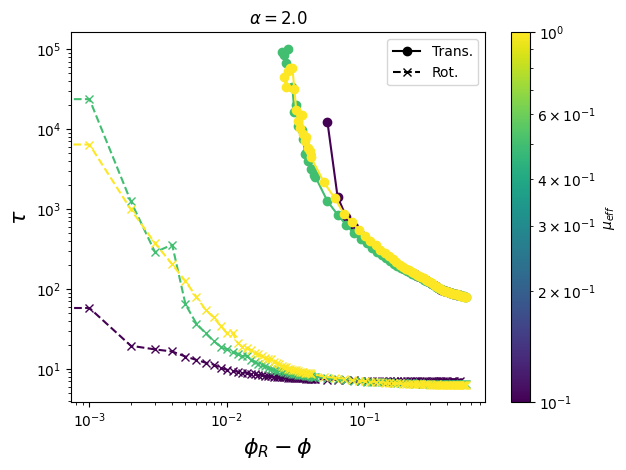

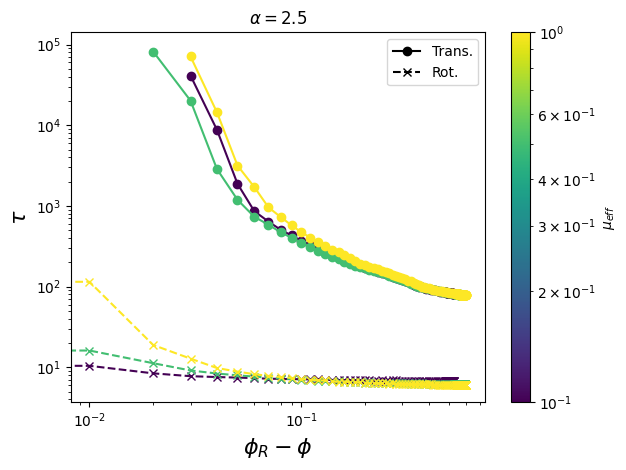

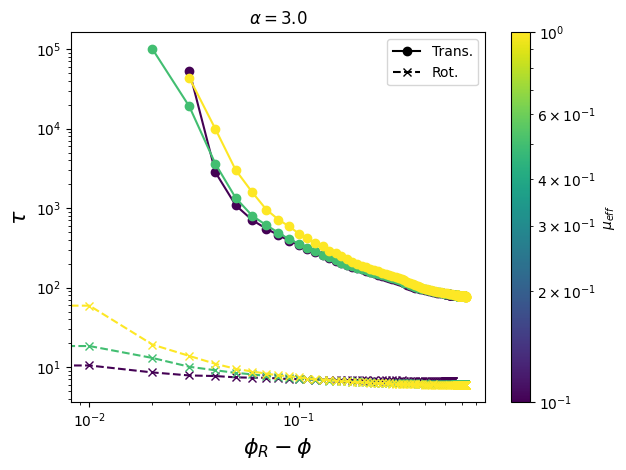

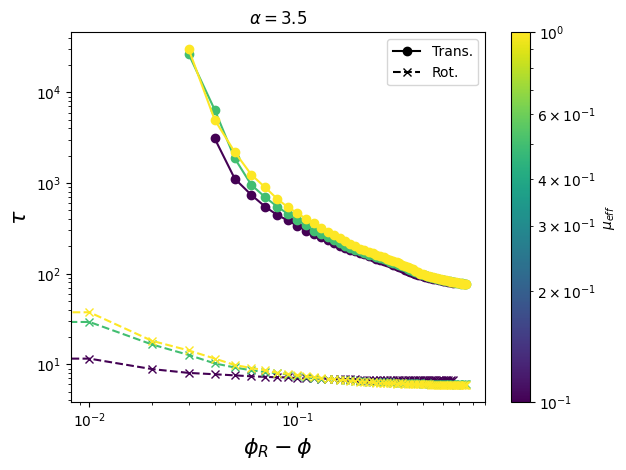

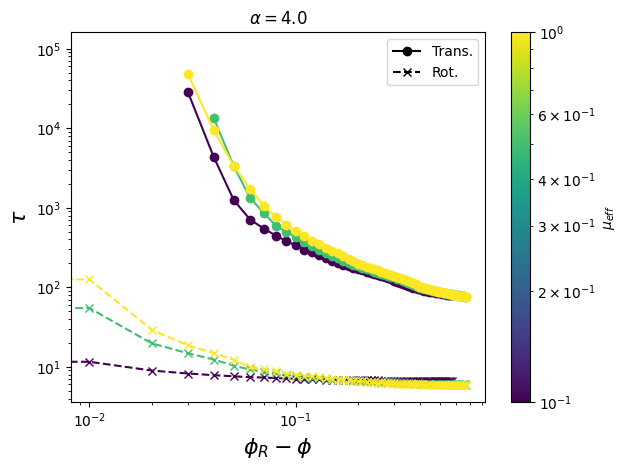

In [12]:
for alpha in pd.unique(tau_df.alpha):
    for mu in pd.unique(tau_df.mu):
        mask = (tau_df.alpha == alpha) & (tau_df.mu == mu)
        x = tau_df[mask].phi.values
        order = np.argsort(x)
        y = tau_df[mask].tau.values[order]
        y_r = tau_df[mask].tau_r.values[order]
        x = np.sort(x)
        x_r = x[np.nanargmax(y_r)]
        plt.plot(x_r - x, y, c=cmap(mu_norm(mu)), marker='o')
        plt.plot(x_r - x, y_r, c=cmap(mu_norm(mu)), marker='x', linestyle='--')
    plt.plot([], [], marker='o', label='Trans.', c='k')
    plt.plot([], [], marker='x', linestyle='--', label='Rot.', c='k')
    plt.legend()
    plt.xlabel(r'$\phi_R - \phi$', fontsize=16)
    plt.ylabel(r'$\tau$', fontsize=16)
    plt.xscale('log')
    plt.yscale('log')
    plt.title(fr'$\alpha=${alpha}')
    sm = plt.cm.ScalarMappable(norm=mu_norm, cmap=cmap)
    sm.set_array(pd.unique(tau_df.mu))
    cbar = plt.colorbar(sm, ax=plt.gca(), label=r'$\mu_{eff}$')
    plt.tight_layout()
    plt.show()

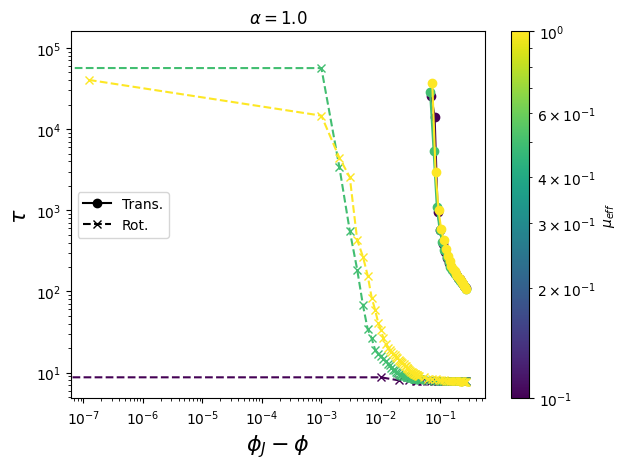

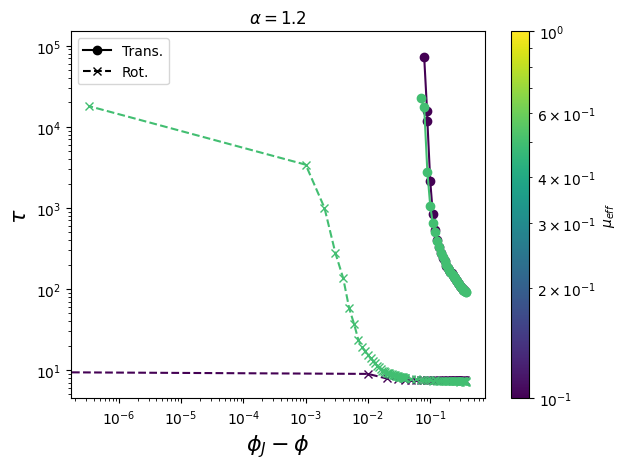

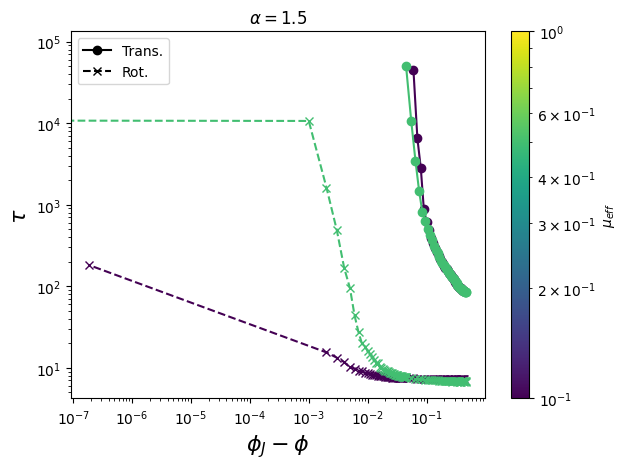

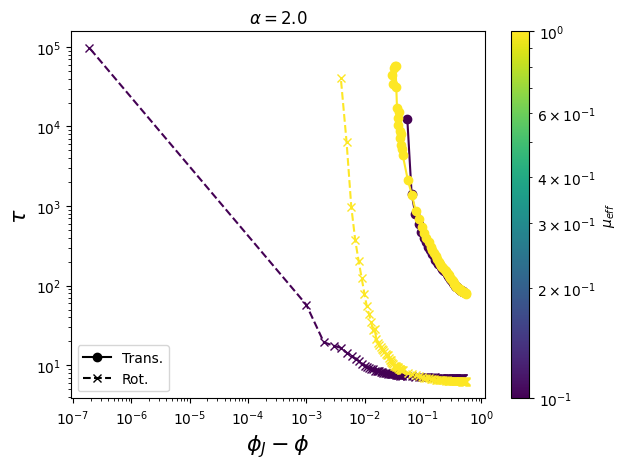

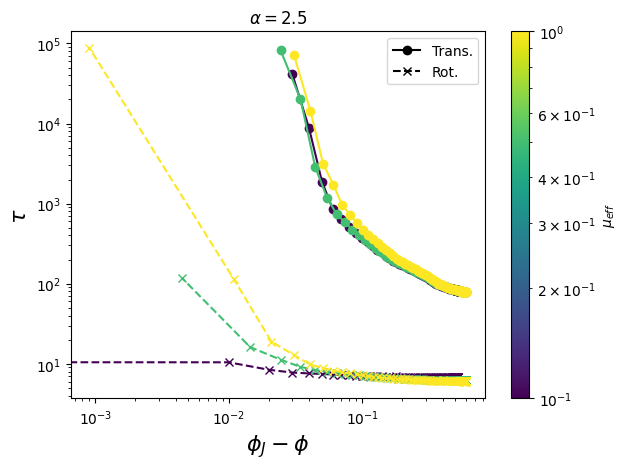

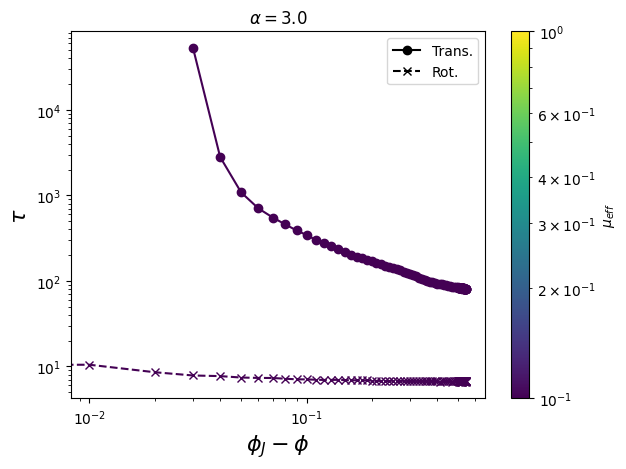

In [76]:
for alpha in pd.unique(tau_df.alpha):
    for mu in pd.unique(tau_df.mu):
        mask = (tau_df.alpha == alpha) & (tau_df.mu == mu)
        x = tau_df[mask].phi.values
        order = np.argsort(x)
        y = tau_df[mask].tau.values[order]
        y_r = tau_df[mask].tau_r.values[order]
        x = np.sort(x)
        mask = (jamming_data['mu'] == mu) & (jamming_data['alpha'] == alpha)
        if not np.any(mask):
            continue
        x_j = jamming_data['phi_j'][mask]
        plt.plot(x_j - x, y, c=cmap(mu_norm(mu)), marker='o')
        plt.plot(x_j - x, y_r, c=cmap(mu_norm(mu)), marker='x', linestyle='--')
    plt.plot([], [], marker='o', label='Trans.', c='k')
    plt.plot([], [], marker='x', linestyle='--', label='Rot.', c='k')
    plt.legend()
    plt.xlabel(r'$\phi_J - \phi$', fontsize=16)
    plt.ylabel(r'$\tau$', fontsize=16)
    plt.xscale('log')
    plt.yscale('log')
    plt.title(fr'$\alpha=${alpha}')
    sm = plt.cm.ScalarMappable(norm=mu_norm, cmap=cmap)
    sm.set_array(pd.unique(tau_df.mu))
    cbar = plt.colorbar(sm, ax=plt.gca(), label=r'$\mu_{eff}$')
    plt.tight_layout()
    plt.show()

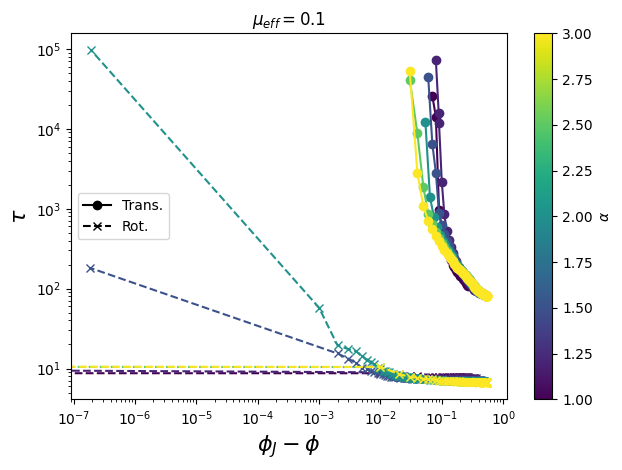

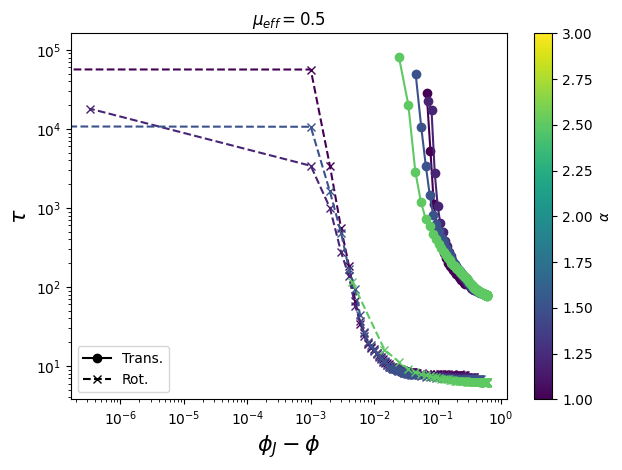

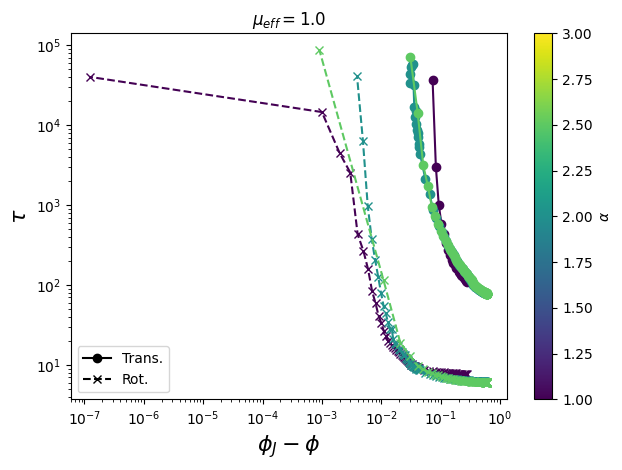

In [79]:
for mu in pd.unique(tau_df.mu):
    for alpha in pd.unique(tau_df.alpha):
        mask = (tau_df.alpha == alpha) & (tau_df.mu == mu)
        x = tau_df[mask].phi.values
        order = np.argsort(x)
        y = tau_df[mask].tau.values[order]
        y_r = tau_df[mask].tau_r.values[order]
        x = np.sort(x)
        mask = (jamming_data['mu'] == mu) & (jamming_data['alpha'] == alpha)
        if not np.any(mask):
            continue
        x_j = jamming_data['phi_j'][mask]
        plt.plot(x_j - x, y, c=cmap(alpha_norm(alpha)), marker='o')
        plt.plot(x_j - x, y_r, c=cmap(alpha_norm(alpha)), marker='x', linestyle='--')
    plt.plot([], [], marker='o', label='Trans.', c='k')
    plt.plot([], [], marker='x', linestyle='--', label='Rot.', c='k')
    plt.legend()
    plt.xlabel(r'$\phi_J - \phi$', fontsize=16)
    plt.ylabel(r'$\tau$', fontsize=16)
    plt.xscale('log')
    plt.yscale('log')
    plt.title(fr'$\mu_{{eff}}=${mu}')
    sm = plt.cm.ScalarMappable(norm=alpha_norm, cmap=cmap)
    sm.set_array(pd.unique(tau_df.alpha))
    cbar = plt.colorbar(sm, ax=plt.gca(), label=r'$\alpha$')
    plt.tight_layout()
    plt.show()

In [75]:
# plot against phi - phi_j

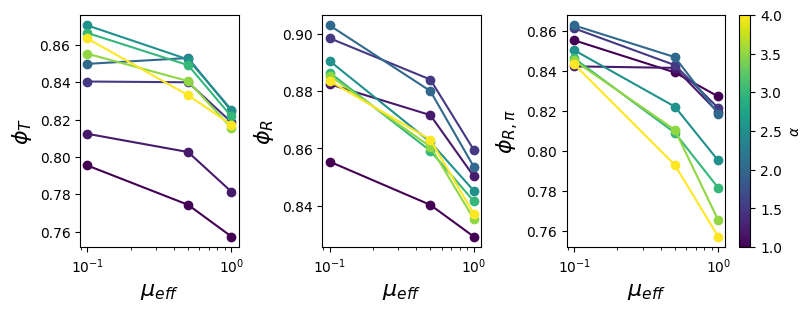

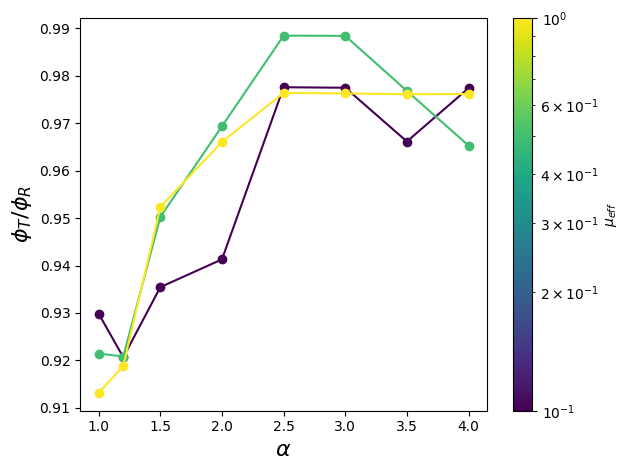

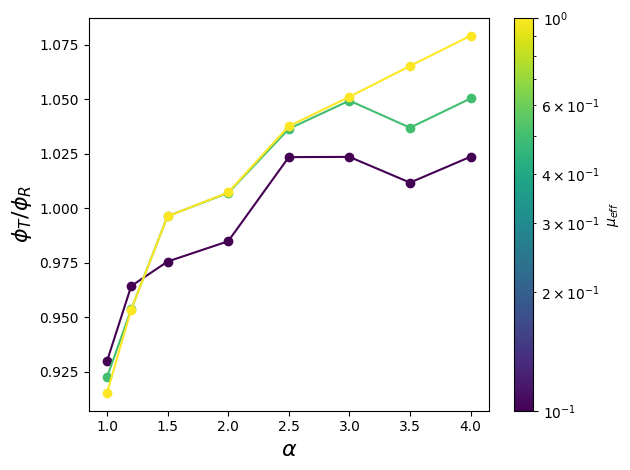

In [38]:
phi_c_df = {
    'alpha': [],
    'mu': [],
    'phi_T': [],
    'phi_R': [],
    'phi_R_PI': [],
}
for alpha in pd.unique(tau_df.alpha):
    for mu in pd.unique(tau_df.mu):
        mask = (tau_df.alpha == alpha) & (tau_df.mu == mu)
        x = tau_df[mask].phi.values
        order = np.argsort(x)
        y = tau_df[mask].tau.values[order]
        y_r = tau_df[mask].tau_r.values[order]
        y_r_pi = tau_df[mask].tau_r_pi.values[order]
        x = np.sort(x)

        phi_c_df['phi_T'].append(x[np.nanargmax(y)])
        phi_c_df['phi_R'].append(x[np.nanargmax(y_r) - 1])
        phi_c_df['phi_R_PI'].append(x[np.nanargmax(y_r_pi) - 1])
        phi_c_df['alpha'].append(alpha)
        phi_c_df['mu'].append(mu)
phi_c_df = pd.DataFrame(phi_c_df)

fig, ax = plt.subplots(1, 3, figsize=(8, 3), constrained_layout=True)
for alpha in pd.unique(phi_c_df.alpha):
    mask = (phi_c_df.alpha == alpha)
    x = phi_c_df.mu[mask].values
    order = np.argsort(x)
    y = phi_c_df.phi_T[mask].values[order]
    y_r = phi_c_df.phi_R[mask].values[order]
    y_r_PI = phi_c_df.phi_R_PI[mask].values[order]
    x = x[order]
    ax[0].plot(x, y, marker='o', c=cmap(alpha_norm(alpha)))
    ax[1].plot(x, y_r, marker='o', c=cmap(alpha_norm(alpha)))
    ax[2].plot(x, y_r_PI, marker='o', c=cmap(alpha_norm(alpha)))
for a in ax:
    a.set_xscale('log')
    a.set_xlabel(r'$\mu_{eff}$', fontsize=16)
ax[0].set_ylabel(r'$\phi_T$', fontsize=16)
ax[1].set_ylabel(r'$\phi_R$', fontsize=16)
ax[2].set_ylabel(r'$\phi_{R,\pi}$', fontsize=16)
sm = plt.cm.ScalarMappable(norm=alpha_norm, cmap=cmap)
sm.set_array(pd.unique(phi_c_df.alpha))
cbar = plt.colorbar(sm, ax=ax[-1], label=r'$\alpha$')
plt.show()

for mu in pd.unique(phi_c_df.mu):
    mask = (phi_c_df.mu == mu)
    x = phi_c_df.alpha[mask].values
    order = np.argsort(x)
    y = phi_c_df.phi_T[mask].values[order]
    y_r = phi_c_df.phi_R[mask].values[order]
    x = x[order]
    plt.plot(x, y / y_r, marker='o', c=cmap(mu_norm(mu)))
plt.xlabel(r'$\alpha$', fontsize=16)
plt.ylabel(r'$\phi_T / \phi_R$', fontsize=16)
sm = plt.cm.ScalarMappable(norm=mu_norm, cmap=cmap)
sm.set_array(pd.unique(phi_c_df.mu))
cbar = plt.colorbar(sm, ax=plt.gca(), label=r'$\mu_{eff}$')
plt.tight_layout()
plt.savefig('TR-ratio-convergence.png', dpi=600)
plt.show()

for mu in pd.unique(phi_c_df.mu):
    mask = (phi_c_df.mu == mu)
    x = phi_c_df.alpha[mask].values
    order = np.argsort(x)
    y = phi_c_df.phi_T[mask].values[order]
    y_r = phi_c_df.phi_R_PI[mask].values[order]
    x = x[order]
    plt.plot(x, y / y_r, marker='o', c=cmap(mu_norm(mu)))
plt.xlabel(r'$\alpha$', fontsize=16)
plt.ylabel(r'$\phi_T / \phi_R$', fontsize=16)
sm = plt.cm.ScalarMappable(norm=mu_norm, cmap=cmap)
sm.set_array(pd.unique(phi_c_df.mu))
cbar = plt.colorbar(sm, ax=plt.gca(), label=r'$\mu_{eff}$')
plt.tight_layout()
plt.savefig('TR-ratio-convergence_PI.png', dpi=600)
plt.show()

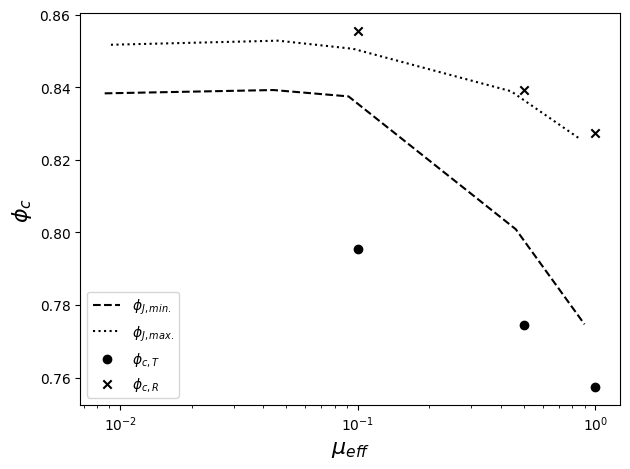

In [68]:
mu_phi_j_min = np.array([[0.008594300333406654, 0.8382986111111111],
[0.04413029616837799, 0.8392123538011697],
[0.09131167633286497, 0.8374579678362574],
[0.461821007306165, 0.8008735380116959],
[0.8993885792023336, 0.7746820175438597],])

mu_phi_j_max = np.array([[0.00913116763328651, 0.851685393258427],
[0.04618210073061655, 0.8528089887640449],
[0.09555714328759787, 0.8505617977528089],
[0.44130296168377947, 0.8388764044943819],
[0.8465089982494057, 0.826067415730337],])

plt.plot(mu_phi_j_min[:, 0], mu_phi_j_min[:, 1], ls='--', c='k', label=r'$\phi_{J,min.}$')
plt.plot(mu_phi_j_max[:, 0], mu_phi_j_max[:, 1], ls=':', c='k', label=r'$\phi_{J,max.}$')
plt.xscale('log')

_df = phi_c_df[phi_c_df.alpha == 1.0]
plt.scatter(_df.mu, _df.phi_T, marker='o', c='k', label=r'$\phi_{c,T}$')
plt.scatter(_df.mu, _df.phi_R_PI, marker='x', c='k', label=r'$\phi_{c,R}$')

plt.legend()

plt.xlabel(r'$\mu_{eff}$', fontsize=16)
plt.ylabel(r'$\phi_c$', fontsize=16)
plt.tight_layout()
plt.savefig('critical-phi-values.png', dpi=600)

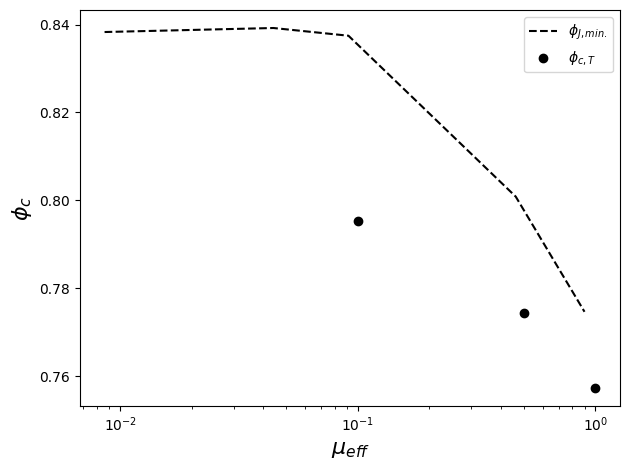

In [174]:
plt.plot(mu_phi_j_min[:, 0], mu_phi_j_min[:, 1], ls='--', c='k', label=r'$\phi_{J,min.}$')
plt.xscale('log')

_df = phi_c_df[phi_c_df.alpha == 1.0]
plt.scatter(_df.mu, _df.phi_T, marker='o', c='k', label=r'$\phi_{c,T}$')

plt.legend()

plt.xlabel(r'$\mu_{eff}$', fontsize=16)
plt.ylabel(r'$\phi_c$', fontsize=16)
plt.tight_layout()
plt.savefig('T-ONLY-critical-phi-values.png', dpi=600)

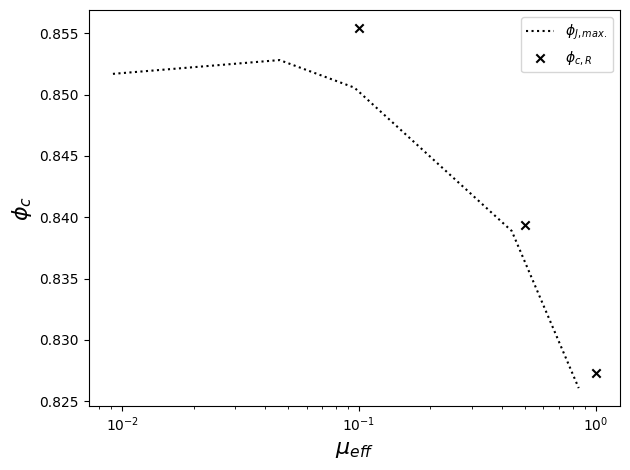

In [176]:
plt.plot(mu_phi_j_max[:, 0], mu_phi_j_max[:, 1], ls=':', c='k', label=r'$\phi_{J,max.}$')
plt.xscale('log')

_df = phi_c_df[phi_c_df.alpha == 1.0]
plt.scatter(_df.mu, _df.phi_R_PI, marker='x', c='k', label=r'$\phi_{c,R}$')

plt.legend()

plt.xlabel(r'$\mu_{eff}$', fontsize=16)
plt.ylabel(r'$\phi_c$', fontsize=16)
plt.tight_layout()
plt.savefig('R-ONLY-critical-phi-values.png', dpi=600)

In [51]:
np.nanargmax(y)

np.int64(20)

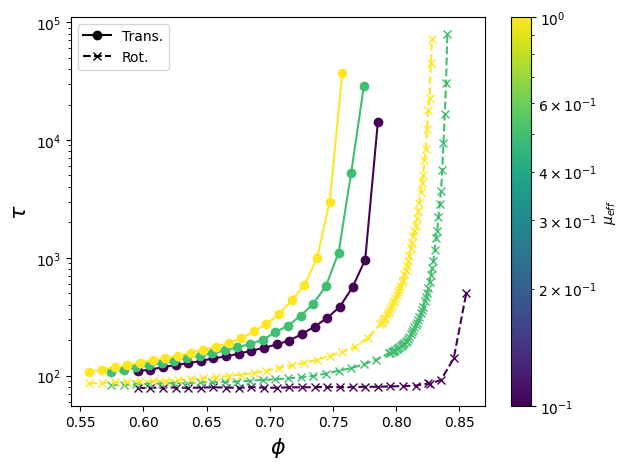

In [56]:
alpha = 1.0
for mu in np.unique(tau_df.mu):
    mask = (tau_df.alpha == alpha) & (tau_df.mu == mu)
    x = tau_df[mask].phi.values
    order = np.argsort(x)
    y = tau_df[mask].tau.values[order]
    y_r = tau_df[mask].tau_r_pi.values[order]
    x = np.sort(x)
    valid = np.ones_like(x).astype(bool)
    valid_r = valid.copy()
    if mu == 1e-1:
        valid[np.nanargmax(y):] = 0
        valid_r[-1] = 0
    plt.plot(x[valid], y[valid], c=cmap(mu_norm(mu)), marker='o')
    plt.plot(x[valid_r], y_r[valid_r], c=cmap(mu_norm(mu)), marker='x', linestyle='--')
plt.plot([], [], marker='o', label='Trans.', c='k')
plt.plot([], [], marker='x', linestyle='--', label='Rot.', c='k')
plt.legend()
plt.xlabel(r'$\phi$', fontsize=16)
plt.ylabel(r'$\tau$', fontsize=16)
plt.yscale('log')

sm = plt.cm.ScalarMappable(norm=mu_norm, cmap=cmap)
sm.set_array(pd.unique(tau_df.mu))
cbar = plt.colorbar(sm, ax=plt.gca(), label=r'$\mu_{eff}$')
plt.tight_layout()
plt.savefig(f'figures/tau-basic-alpha-{alpha}.png', dpi=600)
plt.show()

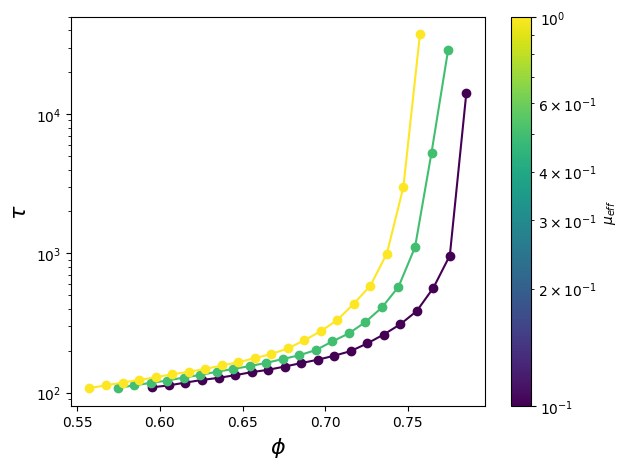

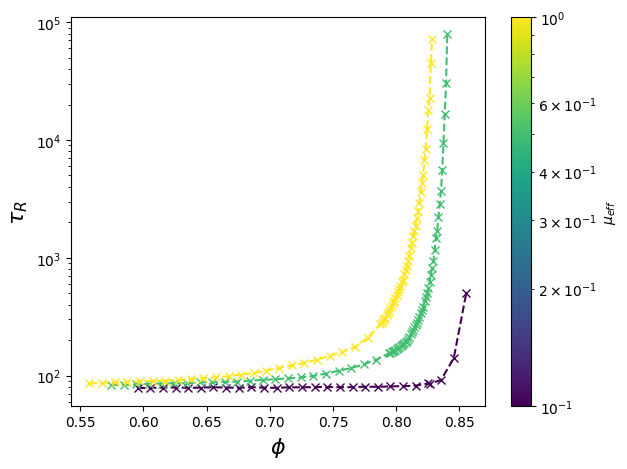

In [183]:
alpha = 1.0
for mu in np.unique(tau_df.mu):
    mask = (tau_df.alpha == alpha) & (tau_df.mu == mu)
    x = tau_df[mask].phi.values
    order = np.argsort(x)
    y = tau_df[mask].tau.values[order]
    y_r = tau_df[mask].tau_r_pi.values[order]
    x = np.sort(x)
    valid = np.ones_like(x).astype(bool)
    valid_r = valid.copy()
    if mu == 1e-1:
        valid[np.nanargmax(y):] = 0
        valid_r[-1] = 0
    plt.plot(x[valid], y[valid], c=cmap(mu_norm(mu)), marker='o')
plt.xlabel(r'$\phi$', fontsize=16)
plt.ylabel(r'$\tau$', fontsize=16)
plt.yscale('log')

sm = plt.cm.ScalarMappable(norm=mu_norm, cmap=cmap)
sm.set_array(pd.unique(tau_df.mu))
cbar = plt.colorbar(sm, ax=plt.gca(), label=r'$\mu_{eff}$')
plt.tight_layout()
plt.savefig(f'figures/T-ONLY-tau-basic-alpha-{alpha}.png', dpi=600)
plt.show()

alpha = 1.0
for mu in np.unique(tau_df.mu):
    mask = (tau_df.alpha == alpha) & (tau_df.mu == mu)
    x = tau_df[mask].phi.values
    order = np.argsort(x)
    y = tau_df[mask].tau.values[order]
    y_r = tau_df[mask].tau_r_pi.values[order]
    x = np.sort(x)
    valid = np.ones_like(x).astype(bool)
    valid_r = valid.copy()
    if mu == 1e-1:
        valid[np.nanargmax(y):] = 0
        valid_r[-1] = 0
    plt.plot(x[valid_r], y_r[valid_r], c=cmap(mu_norm(mu)), marker='x', linestyle='--')
plt.xlabel(r'$\phi$', fontsize=16)
plt.ylabel(r'$\tau_R$', fontsize=16)
plt.yscale('log')

sm = plt.cm.ScalarMappable(norm=mu_norm, cmap=cmap)
sm.set_array(pd.unique(tau_df.mu))
cbar = plt.colorbar(sm, ax=plt.gca(), label=r'$\mu_{eff}$')
plt.tight_layout()
plt.savefig(f'figures/R-ONLY-tau-basic-alpha-{alpha}.png', dpi=600)
plt.show()

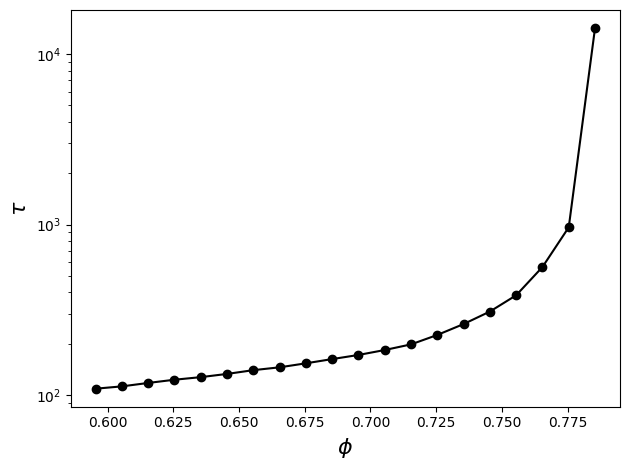

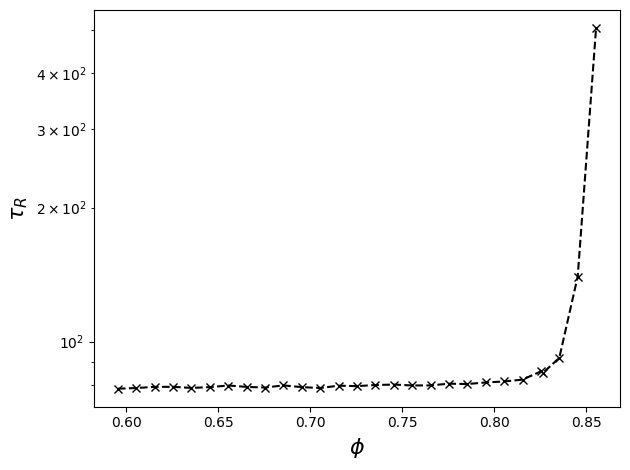

In [171]:
alpha = 1.0
for mu in np.unique(tau_df.mu):
    if mu != 1e-1:
        continue
    mask = (tau_df.alpha == alpha) & (tau_df.mu == mu)
    x = tau_df[mask].phi.values
    order = np.argsort(x)
    y = tau_df[mask].tau.values[order]
    y_r = tau_df[mask].tau_r_pi.values[order]
    x = np.sort(x)
    valid = np.ones_like(x).astype(bool)
    valid_r = valid.copy()
    if mu == 1e-1:
        valid[np.nanargmax(y):] = 0
        valid_r[-1] = 0
    plt.plot(x[valid], y[valid], c='k', marker='o')
plt.xlabel(r'$\phi$', fontsize=16)
plt.ylabel(r'$\tau$', fontsize=16)
plt.yscale('log')
plt.tight_layout()
plt.savefig(f'figures/tau_T.png', dpi=600)
plt.show()

alpha = 1.0
for mu in np.unique(tau_df.mu):
    if mu != 1e-1:
        continue
    mask = (tau_df.alpha == alpha) & (tau_df.mu == mu)
    x = tau_df[mask].phi.values
    order = np.argsort(x)
    y = tau_df[mask].tau.values[order]
    y_r = tau_df[mask].tau_r_pi.values[order]
    x = np.sort(x)
    valid = np.ones_like(x).astype(bool)
    valid_r = valid.copy()
    if mu == 1e-1:
        valid[np.nanargmax(y):] = 0
        valid_r[-1] = 0
    plt.plot(x[valid_r], y_r[valid_r], c='k', marker='x', linestyle='--')
plt.xlabel(r'$\phi$', fontsize=16)
plt.ylabel(r'$\tau_R$', fontsize=16)
plt.yscale('log')
plt.tight_layout()
plt.savefig(f'figures/tau_R.png', dpi=600)
plt.show()

/var/folders/f5/gw8thzr169xd6l47yn540sf80000gn/T/ipykernel_81919/1507478513.py:6: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  plt.scatter(mu, jamming_data['phi_j'][mask], c=cmap(alpha_norm(alpha)))


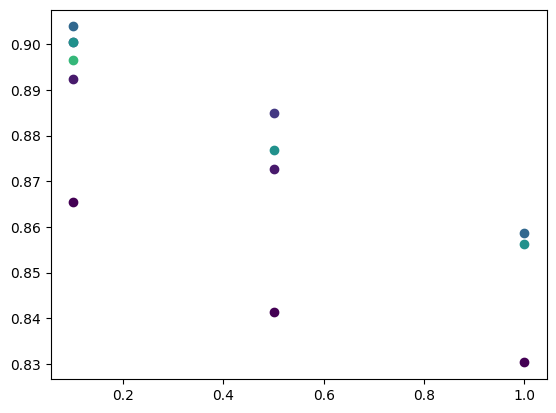

In [17]:
for alpha in np.unique(jamming_data['alpha']):
    for mu in np.unique(jamming_data['mu']):
        mask = (jamming_data['mu'] == mu) & (jamming_data['alpha'] == alpha)
        if not np.any(mask):
            continue
        plt.scatter(mu, jamming_data['phi_j'][mask], c=cmap(alpha_norm(alpha)))

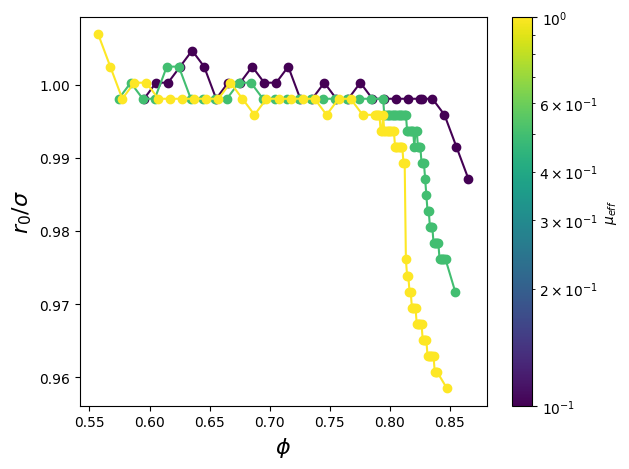

In [155]:
df = pd.read_csv('gr_data.csv')

for mu in pd.unique(df.mu):
    mask = (df.mu == mu)
    x = df.phi[mask].values
    y = df.r_small[mask].values
    y = y[np.argsort(x)]
    x = x[np.argsort(x)]
    plt.plot(x, y, marker='o', c=cmap(mu_norm(mu)))


sm = plt.cm.ScalarMappable(norm=mu_norm, cmap=cmap)
sm.set_array(pd.unique(tau_df.mu))
cbar = plt.colorbar(sm, ax=plt.gca(), label=r'$\mu_{eff}$')

# plt.axvline(0.81)
# plt.axvline(0.82)
# plt.axvline(0.84)

plt.ylabel(r'$r_0/\sigma$', fontsize=16)
plt.xlabel(r'$\phi$', fontsize=16)

plt.tight_layout()
plt.savefig('r-phi.png', dpi=600)

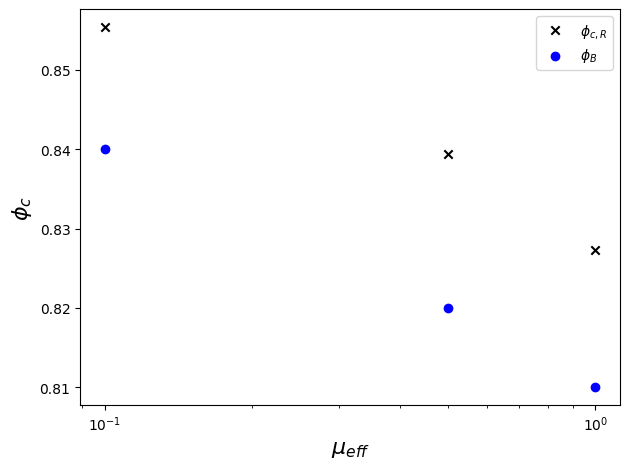

In [162]:
plt.scatter(_df.mu, _df.phi_R_PI, marker='x', c='k', label=r'$\phi_{c,R}$')
plt.scatter([1.0, 0.5, 0.1], [0.81, 0.82, 0.84], c='b', label=r'$\phi_B$')
plt.xscale('log')

plt.legend()

plt.ylabel(r'$\phi_c$', fontsize=16)
plt.xlabel(r'$\mu_{eff}$', fontsize=16)

plt.tight_layout()
plt.savefig('phi_b.png', dpi=600)

(np.float64(0.99436923352609), np.float64(0.9918898806538285))
(np.float64(0.9790446554560382), np.float64(0.9760781788647186))
(np.float64(0.9790446554560382), np.float64(0.9760781788647186))


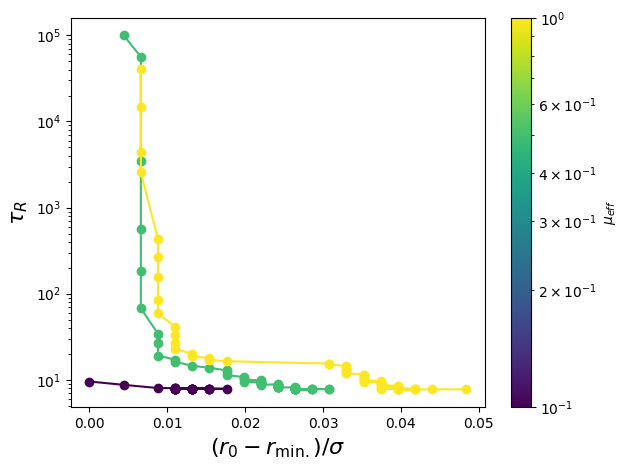

In [152]:
df = pd.read_csv('gr_data.csv')

def get_bumpy_dists(num_vertices, outer_radius, vertex_radius):
    sigma = outer_radius * 2
    sigma_v = vertex_radius * 2
    n_v = num_vertices
    sigma_p_i = sigma - sigma_v
    # the closest center-to-center distance between two particles of the same species at a symmetric contact
    d_0 = (np.cos(np.pi / n_v) / 2 + 1 / 2 + np.sqrt((sigma_v / sigma_p_i) ** 2 - (np.sin(np.pi / n_v) / 2) ** 2)) * sigma_p_i
    # the absolute closest center-to-center distance between two particles of the same species
    d_min = (np.sqrt(np.cos(np.pi / n_v) ** 2 + (sigma_v / sigma_p_i) ** 2 + np.cos(np.pi / n_v) * np.sqrt(4 * (sigma_v / sigma_p_i) ** 2 - np.sin(np.pi / n_v) ** 2))) * sigma_p_i
    return max(d_0, 2 * outer_radius - vertex_radius), d_min

for mu in pd.unique(tau_df.mu):
    for alpha in pd.unique(tau_df.alpha):
        if alpha != 1.0:
            continue
        if mu == 0.1:
            bv = get_bumpy_dists(20, 0.5, 0.22005631)
        elif mu == 0.5:
            bv = get_bumpy_dists(20, 0.5, 0.07443152)
        elif mu == 1.0:
            get_bumpy_dists(20, 0.5, 0.04979934)
        else:
            raise ValueError('unknown mu')
        mask = (tau_df.alpha == alpha) & (tau_df.mu == mu)
        x = tau_df[mask].phi.values
        order = np.argsort(x)
        tau_r = tau_df[mask].tau_r.values[order]
        tau_r_PI = tau_df[mask].tau_r.values[order]

        mask2 = (df.mu == mu)
        x = df.phi[mask2].values
        r = df.r_small[mask2].values
        r = r[np.argsort(x)]

        plt.plot(r - min(r), tau_r, c=cmap(mu_norm(mu)), marker='o')
        print(bv)

plt.yscale('log')


sm = plt.cm.ScalarMappable(norm=mu_norm, cmap=cmap)
sm.set_array(pd.unique(tau_df.mu))
cbar = plt.colorbar(sm, ax=plt.gca(), label=r'$\mu_{eff}$')

plt.ylabel(r'$\tau_R$', fontsize=16)
plt.xlabel(r'$(r_0-r_{\min.})/\sigma$', fontsize=16)

plt.tight_layout()
plt.savefig('r-tau-relation.png', dpi=600)

In [133]:
bv

(np.float64(0.9790446554560382), np.float64(0.9760781788647186))

array([ 5,  7, 11, 13, 19, 31])

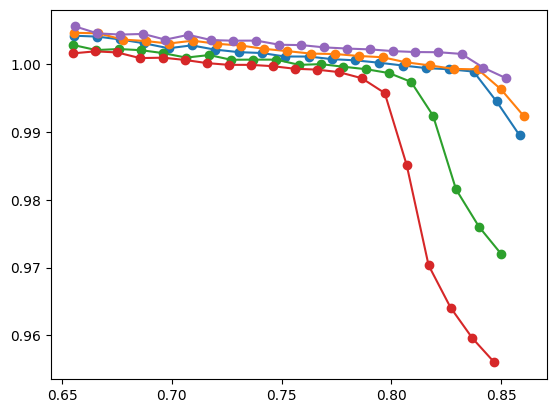

In [93]:
df = pd.read_csv('old-gr-data.csv')

n_bins = 20

for nv in df.nv.unique():
    if nv != 19:
        continue
    for mu in pd.unique(df.mu):
        mask = (df.mu == mu) & (df.nv == nv) & (df.phi > 0.65)
        subset = df[mask]
        if subset.size == 0:
            continue

        if subset.phi.min() == subset.phi.max():
            continue
        phi_bins = np.linspace(subset.phi.min(), subset.phi.max(), n_bins + 1)

        subset = subset.assign(phi_bin=pd.cut(subset.phi, bins=phi_bins))
        binned = subset.groupby('phi_bin', observed=False)['r0_small'].mean()

        bin_centers = binned.index.map(lambda x: x.mid)
        plt.plot(bin_centers, binned.values, marker='o')
df.nv.unique()